In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import os
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('C:\\Users\\ayush\\Downloads\\online_retail_II.csv.zip', compression='zip')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.shape

(1067371, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [6]:
df['Invoice'].nunique()

53628

In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df[df['Invoice'].str.startswith('C') == False]

In [8]:
df['Invoice'] = df['Invoice'].astype(str)
df = df.dropna(subset = ['Customer ID'])

In [9]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [10]:
df['Country'].value_counts()

Country
United Kingdom          725296
Germany                  16703
EIRE                     15745
France                   13813
Netherlands               5093
Spain                     3720
Belgium                   3069
Switzerland               3012
Portugal                  2446
Australia                 1815
Channel Islands           1569
Italy                     1468
Norway                    1437
Sweden                    1319
Cyprus                    1155
Finland                   1032
Austria                    922
Denmark                    798
Greece                     657
Unspecified                521
Poland                     512
Japan                      485
USA                        409
United Arab Emirates       383
Singapore                  339
Israel                     322
Malta                      282
Iceland                    253
Canada                     228
Lithuania                  189
RSA                        123
Brazil                      94


In [11]:
df['StockCode'] = df['StockCode'].astype(str)
df['StockCode'] = df['StockCode'].str.replace(' ', '')

In [12]:
df[df['Quantity']>0].value_counts()

Invoice  StockCode  Description                          Quantity  InvoiceDate          Price  Customer ID  Country       
555524   22698      PINK REGENCY TEACUP AND SAUCER       1         2011-06-05 11:37:00  2.95   16923.0      United Kingdom    20
         22697      GREEN REGENCY TEACUP AND SAUCER      1         2011-06-05 11:37:00  2.95   16923.0      United Kingdom    12
537224   70007      HI TEC ALPINE HAND WARMER            1         2010-12-05 16:24:00  1.65   13174.0      United Kingdom    10
572861   22775      PURPLE DRAWERKNOB ACRYLIC EDWARDIAN  12        2011-10-26 12:46:00  1.25   14102.0      United Kingdom     8
536796   21967      PACK OF 12 SKULL TISSUES             1         2010-12-02 15:46:00  0.29   15574.0      United Kingdom     6
                                                                                                                              ..
581585   84946      ANTIQUE SILVER T-LIGHT GLASS         12        2011-12-09 12:31:00  1.25   15804.0 

In [13]:
df[df['Price']>0].value_counts()

Invoice  StockCode  Description                          Quantity  InvoiceDate          Price  Customer ID  Country       
555524   22698      PINK REGENCY TEACUP AND SAUCER       1         2011-06-05 11:37:00  2.95   16923.0      United Kingdom    20
         22697      GREEN REGENCY TEACUP AND SAUCER      1         2011-06-05 11:37:00  2.95   16923.0      United Kingdom    12
537224   70007      HI TEC ALPINE HAND WARMER            1         2010-12-05 16:24:00  1.65   13174.0      United Kingdom    10
572861   22775      PURPLE DRAWERKNOB ACRYLIC EDWARDIAN  12        2011-10-26 12:46:00  1.25   14102.0      United Kingdom     8
502660   17021      NAMASTE SWAGAT INCENSE               6         2010-03-25 17:18:00  0.30   13187.0      United Kingdom     6
                                                                                                                              ..
581585   84946      ANTIQUE SILVER T-LIGHT GLASS         12        2011-12-09 12:31:00  1.25   15804.0 

In [14]:
df['StockCode'].isnull().sum()
df.drop(columns = 'Description',inplace = True)

In [15]:
df['StockCode_num'] = df['StockCode'].str.extract(r'(\d+)')
df['StockCode_alpha'] = df['StockCode'].str.extract(r'([A-Za-z]+)')

In [16]:
df['StockCode_alpha'].isnull().mean()

np.float64(0.8863335071125344)

In [17]:
df['StockCode_alpha'].value_counts(dropna=False).head(20)


StockCode_alpha
NaN     714048
B        24982
A        21892
C        10881
D         6418
L         4087
E         3851
F         3372
S         3221
G         2660
POST      1838
P         1627
M         1455
N         1145
W          844
BL         838
K          687
H          417
U          382
J          344
Name: count, dtype: int64

In [18]:
df.drop(columns = ['StockCode_alpha'], inplace = True)
df.head(4)

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country,StockCode_num
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,85048
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,79323
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,79323
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,22041


In [19]:
# df['InvoiceDate'].unique.value_count()

In [20]:
df.head(6)

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID,Country,StockCode_num
0,489434,85048,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,85048
1,489434,79323P,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,79323
2,489434,79323W,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,79323
3,489434,22041,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,22041
4,489434,21232,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,21232
5,489434,22064,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,22064


In [21]:
df.drop(columns = ['StockCode'], inplace = True)

In [22]:
df.head(5)

,Invoice,Quantity,InvoiceDate,Price,Customer ID,Country,StockCode_num
0,489434,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,85048
1,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,79323
2,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,79323
3,489434,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,22041
4,489434,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,21232


In [23]:
df['Revenue']= df['Quantity']*df['Price']
df['Revenue']

0           83.40
1           81.00
2           81.00
3          100.80
4           30.00
            ...  
1067366     12.60
1067367     16.60
1067368     16.60
1067369     14.85
1067370     18.00
Name: Revenue, Length: 805620, dtype: float64

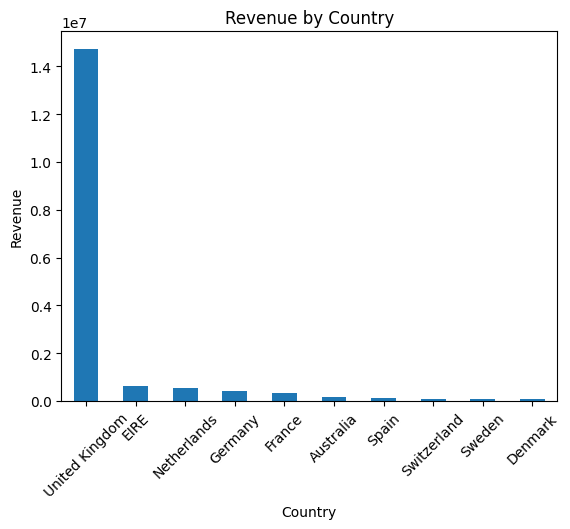

In [24]:
df.groupby('Country')['Revenue'].sum().sort_values(ascending = False).head(10).plot(kind = 'bar')
plt.title('Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation = 45)
plt.show()

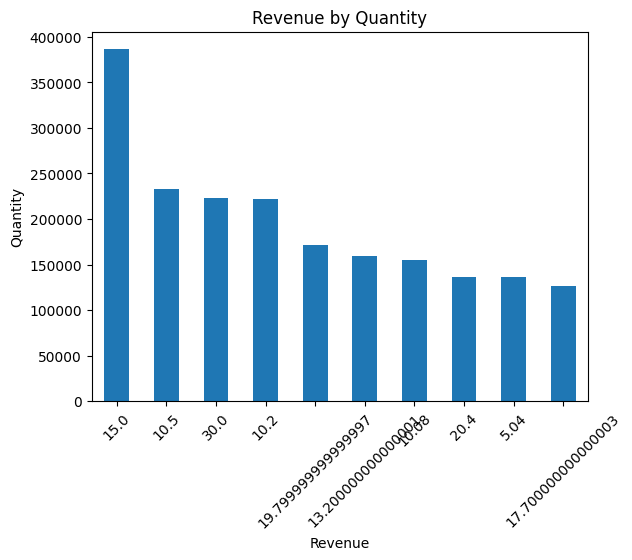

In [25]:
df.groupby('Revenue')['Quantity'].sum().sort_values(ascending = False).head(10).plot(kind = 'bar')
plt.title('Revenue by Quantity')
plt.xlabel('Revenue')
plt.ylabel('Quantity')
plt.xticks(rotation = 45)
plt.show()

In [26]:
df['Invoice'].value_counts()

Invoice
576339    542
579196    533
580727    529
578270    442
573576    435
         ... 
500590      1
510423      1
581458      1
581459      1
510351      1
Name: count, Length: 36975, dtype: int64

In [27]:
snapshot_date = pd.Timestamp('2011-12-10')
past_data = df[df['InvoiceDate'] < snapshot_date]
future_data = df[df['InvoiceDate'] >= snapshot_date]

In [28]:
recency = past_data.groupby('Customer ID')['InvoiceDate'].max()

In [29]:
frequency = past_data.groupby('Customer ID')['Invoice'].nunique()

In [30]:
monetory = past_data.groupby('Customer ID')['Revenue'].mean()

In [31]:
rfm = pd.DataFrame({'Recency': recency, 'Frequency': frequency, 'Monetory': monetory})

In [32]:
rfm['Recency'] = (snapshot_date - rfm['Recency']).dt.days

In [33]:
rfm.head()

,Recency,Frequency,Monetory
Customer ID,,,
12346.0,325,12,2281.072353
12347.0,2,8,22.266087
12348.0,75,5,39.596078
12349.0,18,4,25.306800
12350.0,310,1,19.670588


In [34]:
first_purcahase = past_data.groupby('Customer ID')['InvoiceDate'].min()
rfm['T'] = (snapshot_date - first_purcahase).dt.days
rfm['Recency_weeks'] = rfm['Recency'] / 7
rfm['T_weeks'] = rfm['T'] / 7

Low Recency + high Frequency =  Loyal Active Customer :)
High Recency + Low Frequency = Likely Inactive :(
High Monetory + Low Frequency = Ocassional Big Spender :|

In [35]:
rfm[rfm['Monetory'] < 0].value_counts()

Series([], Name: count, dtype: int64)

In [36]:
df = df.merge(rfm, on = 'Customer ID', how = 'left')
print(df.columns.tolist())

['Invoice', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'StockCode_num', 'Revenue', 'Recency', 'Frequency', 'Monetory', 'T', 'Recency_weeks', 'T_weeks']


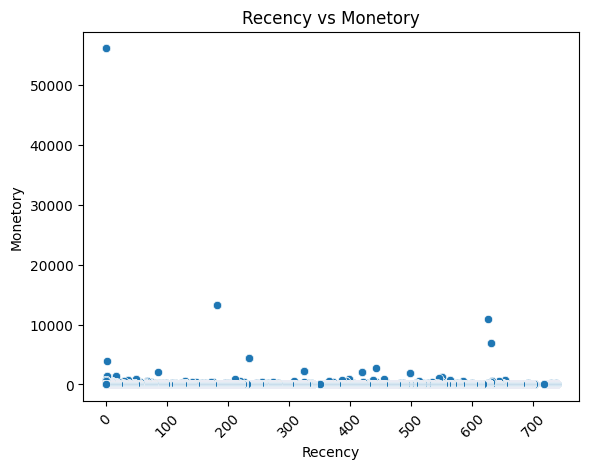

In [37]:
sns.scatterplot(data = df, x = 'Recency', y = 'Monetory')
plt.title('Recency vs Monetory')
plt.xlabel('Recency')
plt.ylabel('Monetory')
plt.xticks(rotation = 45)
plt.show()

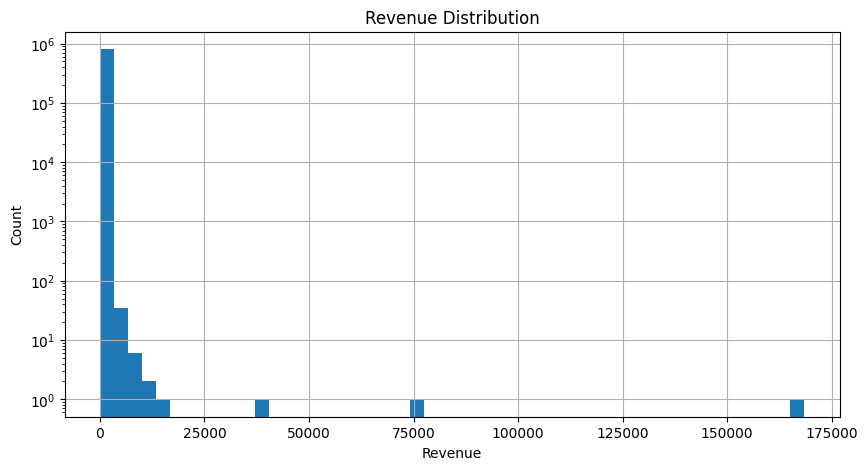

In [38]:
plt.figure(figsize = (10,5))
df['Revenue'].hist(bins = 50,log = True)
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Count')
plt.show()

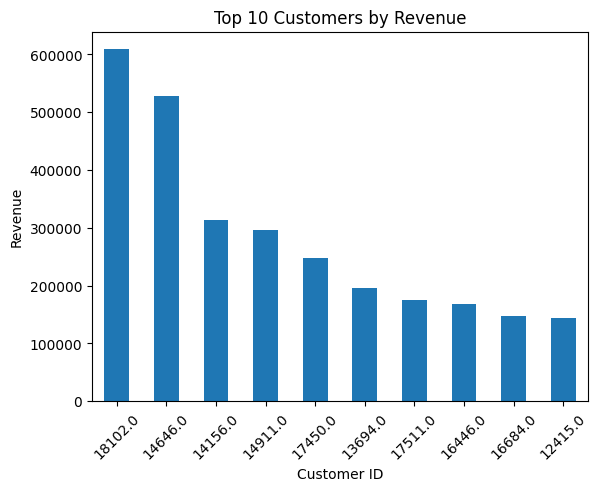

In [39]:
# Top customers by Revenue
top_customers = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending = False).head(10)
top_customers.plot(kind = 'bar')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.xticks(rotation = 45)
plt.show()

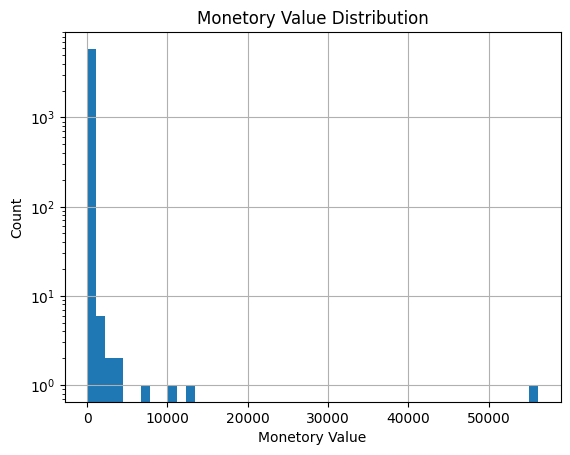

In [40]:
# monetory value distribution
customer_monetory = df.groupby('Customer ID')['Revenue'].mean()
customer_monetory.hist(bins = 50, log = True)
plt.title('Monetory Value Distribution')
plt.xlabel('Monetory Value')
plt.ylabel('Count')
plt.show()

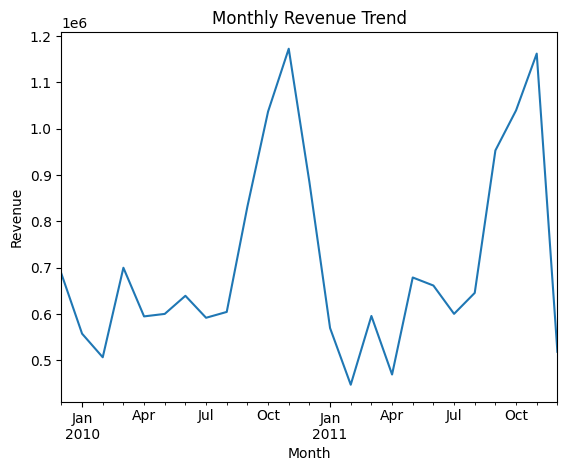

In [41]:
# Montly Revenue trend 
montly_revenue = df.set_index('InvoiceDate').resample('M')['Revenue'].sum()
montly_revenue.plot()
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

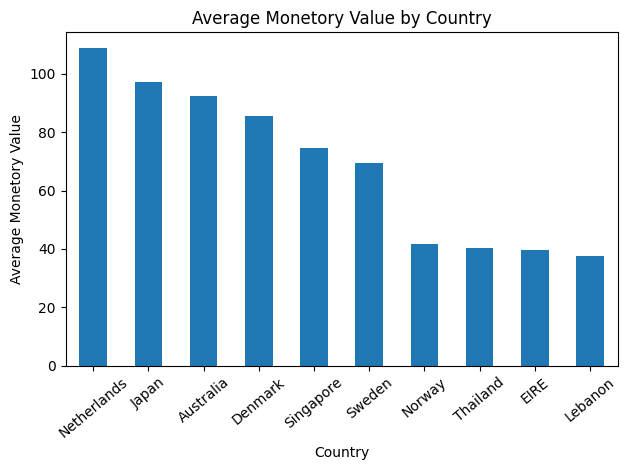

In [42]:
# Average Monetory Value by Country
df.groupby('Country')['Monetory'].mean().sort_values(ascending = False).head(10).plot(kind = 'bar')
plt.title('Average Monetory Value by Country')
plt.xlabel('Country')
plt.ylabel('Average Monetory Value')
plt.xticks(rotation = 40)
plt.tight_layout()
plt.show()

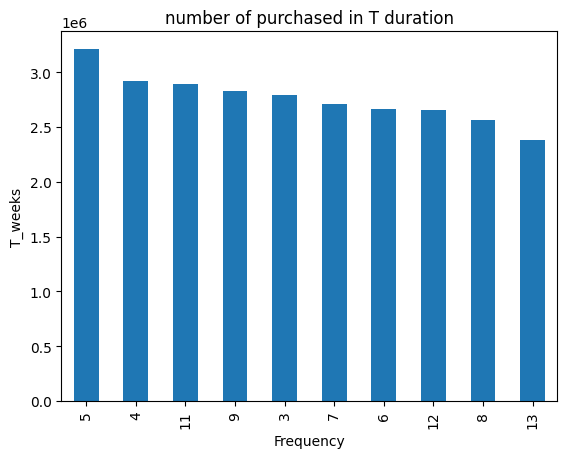

In [43]:
df.groupby('Frequency')['T_weeks'].sum().sort_values(ascending = False).head(10).plot(kind = 'bar')
plt.title('number of purchased in T duration')
plt.xlabel('Frequency')
plt.ylabel('T_weeks')
plt.show()

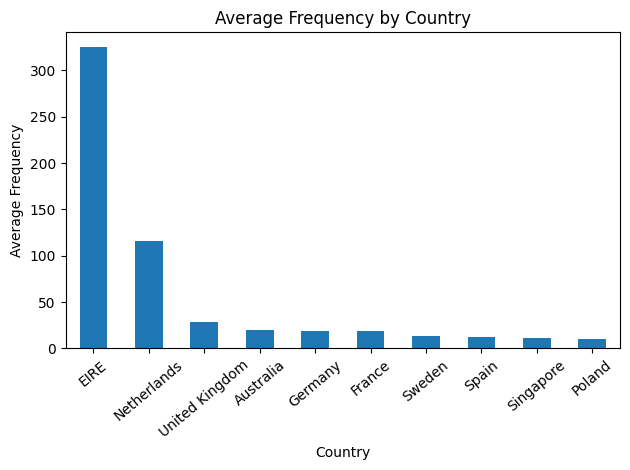

In [44]:
# Average Frequency by Country
df.groupby('Country')['Frequency'].mean().sort_values(ascending = False).head(10).plot(kind = 'bar')
plt.title('Average Frequency by Country')
plt.xlabel('Country')
plt.ylabel('Average Frequency')
plt.xticks(rotation = 40)
plt.tight_layout()
plt.show()

Customers from the netherland generated the highest average monetary contribution,whereas EIRE exhibited the highest transcation Frequency ,indicating stronger repeat purchasing behaviour 

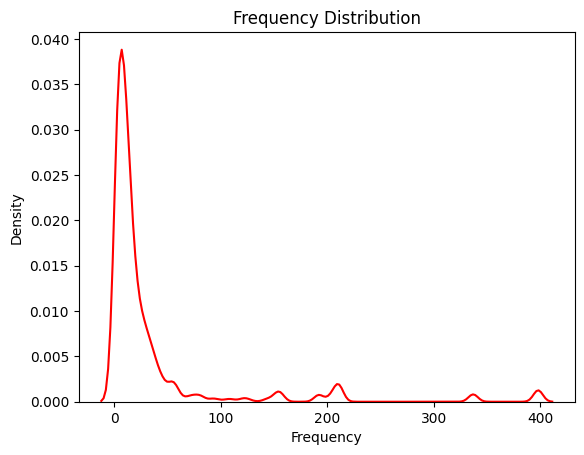

In [45]:
sns.kdeplot(data = df , x= df['Frequency'],color = 'red')
plt.title('Frequency Distribution')
plt.show()

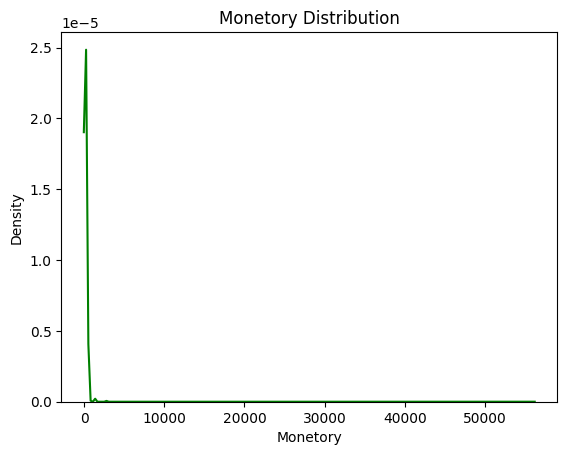

In [46]:
sns.kdeplot(data = df , x= df['Monetory'],color = 'green')
plt.title('Monetory Distribution')
plt.show()

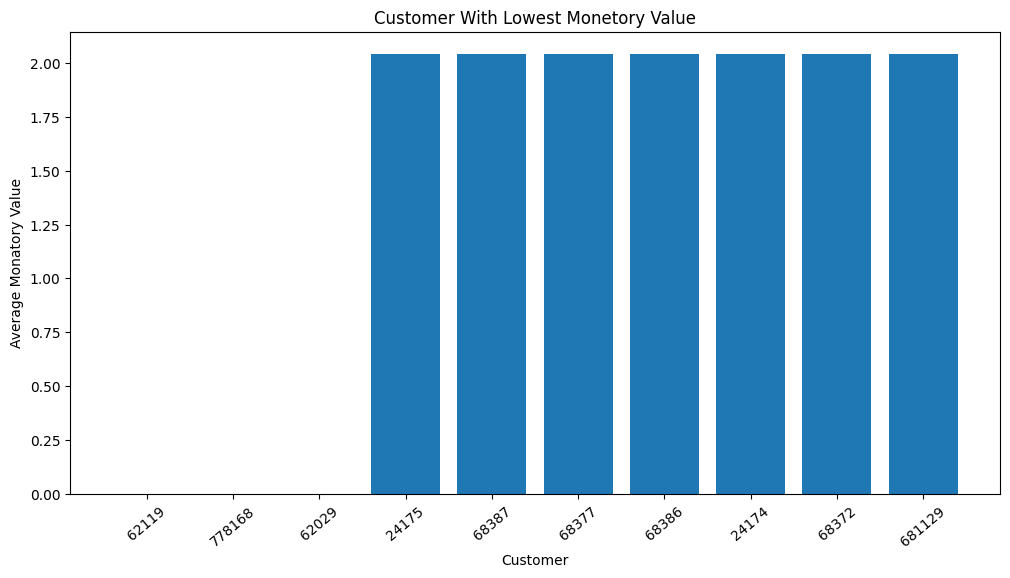

In [47]:
least_cus = df[df['Monetory'] <= df['Monetory'].quantile(0.45)]
least_cus = least_cus.sort_values(by = 'Monetory').head(10)
plt.figure(figsize = (12,6))
plt.bar(
    least_cus.index.astype(str),
    least_cus['Monetory']
)

plt.title('Customer With Lowest Monetory Value')
plt.xlabel('Customer')
plt.ylabel('Average Monatory Value')
plt.xticks(rotation = 40)
plt.show()

The Graph shows Customers with the  lowest Monetory Values.These Customers contribute Less Revenue and May Require Targeted strategies to Improve Customer Value

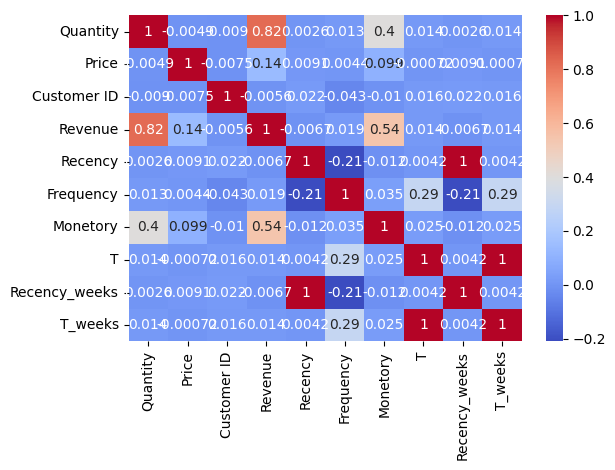

In [48]:
corr = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr,annot = True,cmap = 'coolwarm')
plt.tight_layout()
plt.show()

BG/NBD MODEL

In [49]:
pip install lifetimes

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\ayush\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [50]:
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter

In [51]:
df_gg = df[df['Frequency'] > 1].copy()

In [52]:
print("Number of customers with Recency > T:", (df['Recency_weeks'] > df['T_weeks']).sum())

Number of customers with Recency > T: 0


In [53]:
df_gg = df.drop_duplicates(subset='Customer ID').copy()
df_gg = df_gg[df_gg['Frequency'] > 1]
df_gg = df_gg[df_gg['Frequency'] <= 50]
df_gg = df_gg[df_gg['Monetory'] <= 500]
df_gg = df_gg[df_gg['Monetory'] > 0]

print("Customers:", len(df_gg))
print(df_gg['Frequency'].describe())

Customers: 4176
count    4176.000000
mean        7.130508
std         7.090685
min         2.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        48.000000
Name: Frequency, dtype: float64


In [54]:
print(df.columns.tolist())

['Invoice', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'StockCode_num', 'Revenue', 'Recency', 'Frequency', 'Monetory', 'T', 'Recency_weeks', 'T_weeks']


In [55]:
df_gg = df_gg[df_gg['Frequency'] <= 50]
df_gg = df_gg[df_gg['Monetory'] <= 500]
print('Remaining Customers:',len(df_gg))
print(df_gg['Frequency'].describe())

Remaining Customers: 4176
count    4176.000000
mean        7.130508
std         7.090685
min         2.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        48.000000
Name: Frequency, dtype: float64


In [56]:
print(df_gg[['Frequency','Monetory','Recency_weeks','T_weeks']].describe())

         Frequency     Monetory  Recency_weeks      T_weeks
count  4176.000000  4176.000000    4176.000000  4176.000000
mean      7.130508    25.672497      20.420738    73.904728
std       7.090685    37.877698      24.026208    29.108215
min       2.000000     2.042182       0.000000     1.285714
25%       3.000000    11.456616       2.714286    57.428571
50%       5.000000    17.569433       8.571429    83.071429
75%       9.000000    24.220765      32.285714    97.714286
max      48.000000   495.000000     105.428571   105.428571


In [57]:
bgf = BetaGeoFitter(penalizer_coef = 0.5)
bgf.fit(df_gg['Frequency'], df_gg['Recency_weeks'], df_gg['T_weeks'])
print(bgf)

<lifetimes.BetaGeoFitter: fitted with 4176 subjects, a: 0.27, alpha: 0.01, b: 0.55, r: 0.21>


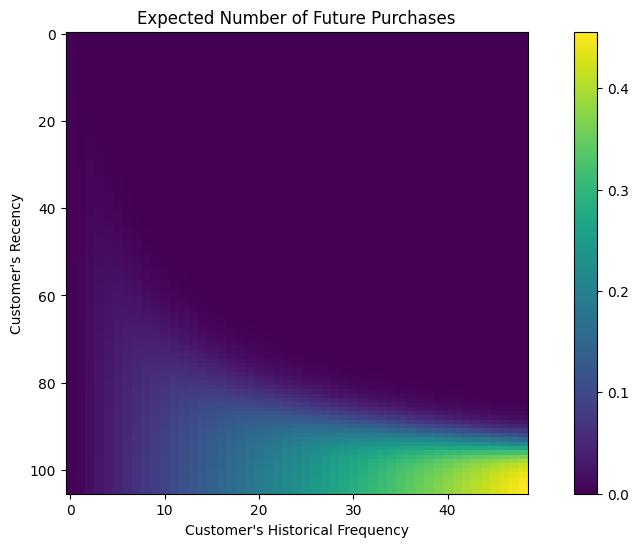

In [58]:
from lifetimes.plotting import plot_frequency_recency_matrix
plt.figure(figsize = (12,6))
plot_frequency_recency_matrix(bgf)
plt.title('Expected Number of Future Purchases')
plt.show()

Customers with high Frequency and Recent Purchases are more Likely to Buy again in the Future.lower Frequency and inactive customers show lower expected future purchases

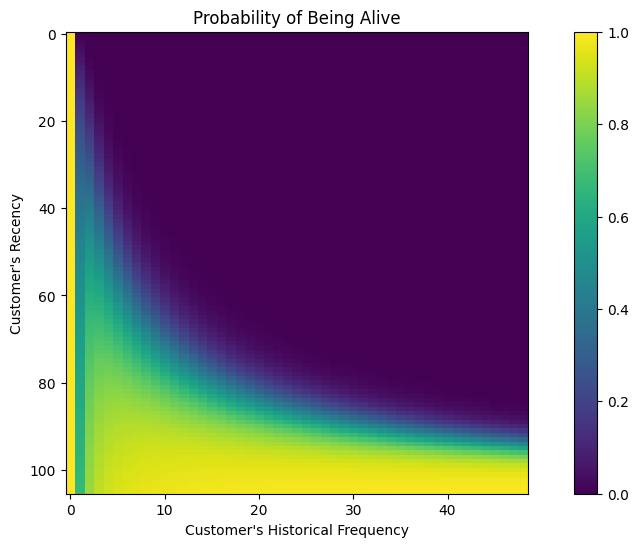

In [59]:
from lifetimes.plotting import plot_probability_alive_matrix
plt.figure(figsize = (12,6))
plot_probability_alive_matrix(bgf)
plt.title('Probability of Being Alive')
plt.show()

Customers with Recent Purchases have a higher probabiliy of remaining active,whereas inactive Customers are More likely to Churn

<Figure size 1200x600 with 0 Axes>

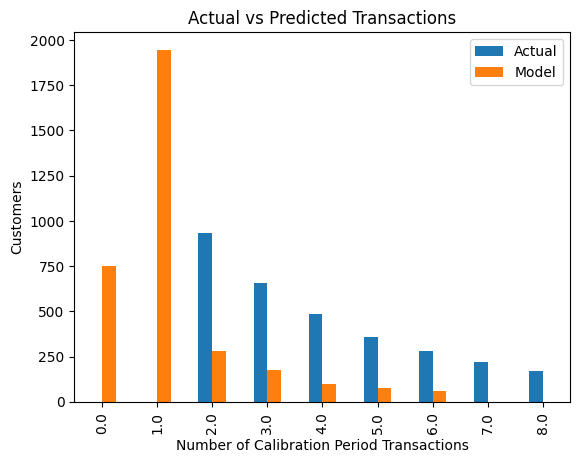

In [60]:
from lifetimes.plotting import plot_period_transactions
plt.figure(figsize = (12,6))
plot_period_transactions(bgf)
plt.title('Actual vs Predicted Transactions')
plt.show()

The BG/NBD Model captures the general Transaction trend,where Most Customers make Fewer Purchases and Only a small Number of Customers are high-Frequency Buyers..
The transaction distribution indicates that a large number of customers made only one or a few purchases before becoming inactive, suggesting possible customer churn. Only a smaller group of customers continued making repeated transactions, representing loyal and high-value customers...
The BG/NBD model uses historical transaction patterns to predict future purchases, but real customer behavior can change due to external and seasonal factors, leading to prediction differences..
Model shows some Calibration Issues due to Item-level transaction data,order -level aggregation would improve accuracy

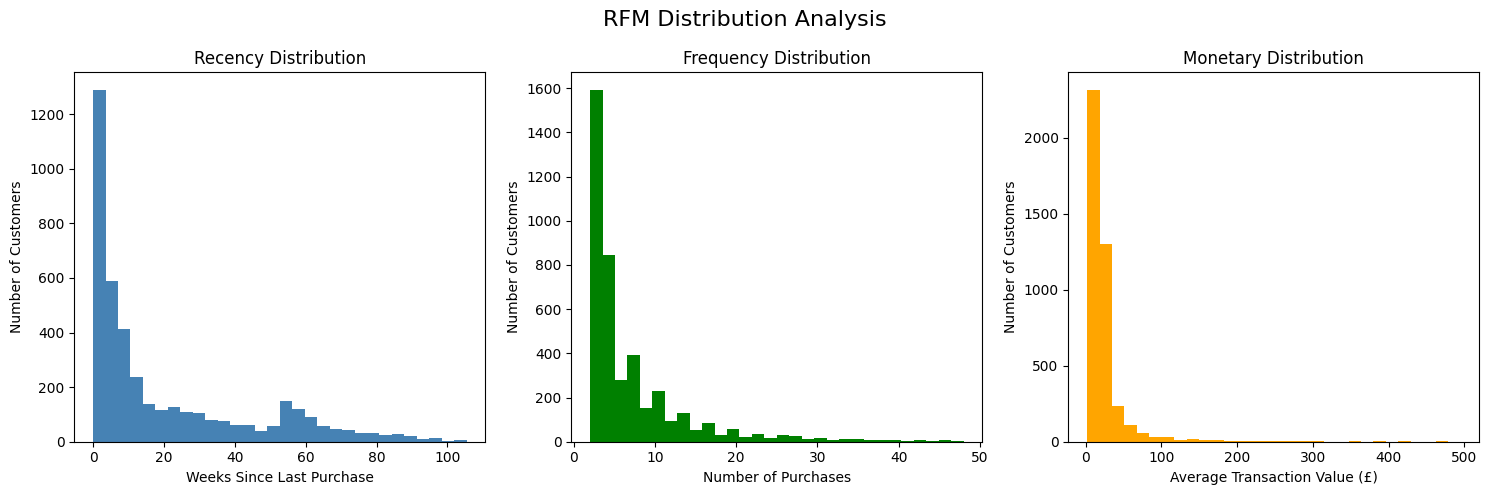

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recency
axes[0].hist(df_gg['Recency_weeks'], bins=30, color='steelblue')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Weeks Since Last Purchase')
axes[0].set_ylabel('Number of Customers')

# Frequency
axes[1].hist(df_gg['Frequency'], bins=30, color='green')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of Purchases')
axes[1].set_ylabel('Number of Customers')

# Monetary
axes[2].hist(df_gg['Monetory'], bins=30, color='orange')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Average Transaction Value (£)')
axes[2].set_ylabel('Number of Customers')

plt.suptitle('RFM Distribution Analysis', fontsize=16)
plt.tight_layout()
plt.show()

In [62]:
from lifetimes import GammaGammaFitter
ggf = GammaGammaFitter(penalizer_coef = 0.01)
ggf.fit(df_gg['Frequency'], df_gg['Monetory'])
print(ggf)

<lifetimes.GammaGammaFitter: fitted with 4176 subjects, p: 3.49, q: 1.08, v: 3.34>


In [63]:
df_gg['Predicted_monetory'] = ggf.conditional_expected_average_profit(df_gg['Frequency'], df_gg['Monetory'])
print(df_gg['Predicted_monetory'].describe())

count    4176.000000
mean       26.361588
std        37.651791
min         2.588311
25%        12.151774
50%        18.301440
75%        24.896034
max       490.733314
Name: Predicted_monetory, dtype: float64


In [64]:
df_gg['CLV'] = ggf.customer_lifetime_value(bgf, df_gg['Frequency'], df_gg['Recency_weeks'], df_gg['T_weeks'], df_gg['Monetory'], time = 12,  discount_rate = 0.01)
print(df_gg['CLV'].describe())
print(df_gg[['Frequency','Monetory','CLV']].describe())

count     4.176000e+03
mean      9.090851e+01
std       4.313671e+02
min      1.505219e-171
25%       2.826255e-07
50%       7.964751e-01
75%       7.499284e+01
max       1.450595e+04
Name: CLV, dtype: float64
         Frequency     Monetory            CLV
count  4176.000000  4176.000000   4.176000e+03
mean      7.130508    25.672497   9.090851e+01
std       7.090685    37.877698   4.313671e+02
min       2.000000     2.042182  1.505219e-171
25%       3.000000    11.456616   2.826255e-07
50%       5.000000    17.569433   7.964751e-01
75%       9.000000    24.220765   7.499284e+01
max      48.000000   495.000000   1.450595e+04


## CLV Analysis Results - Data Interpretation

### Frequency (Purchase Frequency)
- Average customer made **7 purchases** in the observation period
- Minimum is 2 (filtered intentionally for Gamma-Gamma model)
- 50% of customers made **5 or fewer purchases**
- Top customer made **48 purchases** — highly loyal buyer
- Most customers fall in **2-9 purchase range** (typical retail behavior)

### Monetary (Average Transaction Value)
- Average customer spends **£25.67 per transaction**
- 50% of customers spend **£17 or less** per order
- Top spender averages **£495 per order** — premium customer
- Low minimum (£2) suggests some customers buy very cheap items
- Healthy spread indicates **diverse customer spending behavior**

### CLV (Customer Lifetime Value - 12 Months Prediction)
- Average customer is worth **£90.9 over next 12 months**
- **Bottom 50% have near-zero CLV** — predicted as churned/inactive
- Top 25% of customers are worth **£75 or more** each
- Top customer is worth **£14,505** — extremely high-value VIP
- Large gap between median and mean indicates **right-skewed distribution**
  meaning a small group of customers drives most of the revenue

### Key Business Insights
- Classic **Pareto Principle (80/20 rule)** observed:
  small % of customers generating majority of future value
- **50% customer churn** predicted — retention campaigns needed
- High-value customers (CLV > £500) should receive **VIP treatment**
- Low CLV customers need **re-engagement campaigns**
- Focus marketing budget on **top 25% customers** for maximum ROI

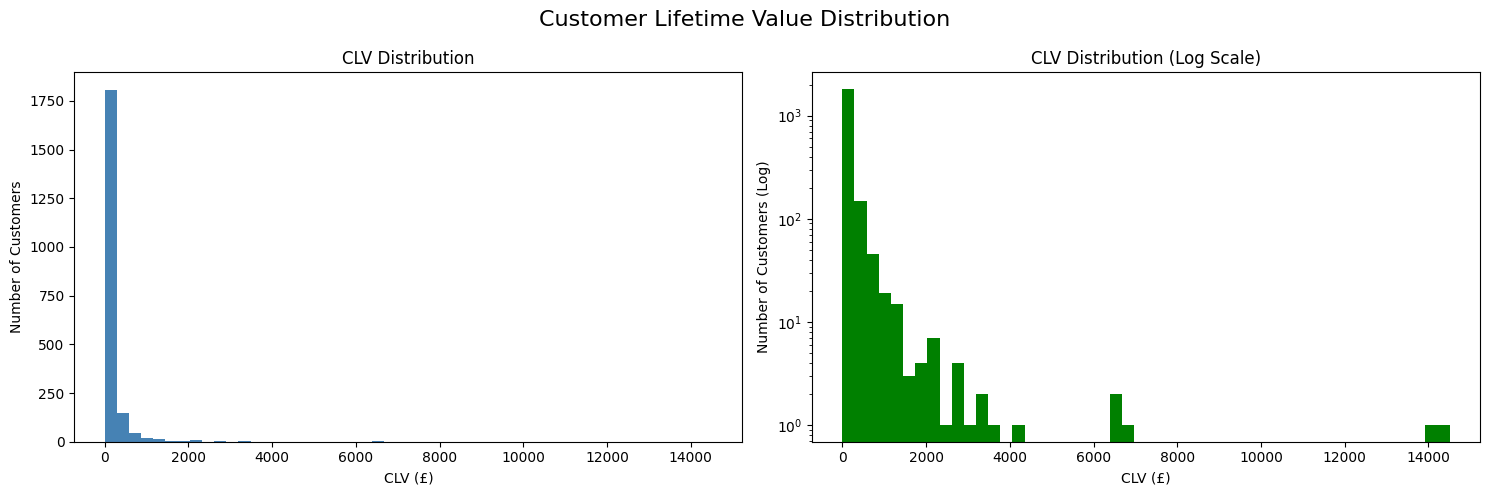

In [65]:
clv_filtered = df_gg[df_gg['CLV'] > 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Normal scale
axes[0].hist(clv_filtered['CLV'], bins=50, color='steelblue')
axes[0].set_title('CLV Distribution')
axes[0].set_xlabel('CLV (£)')
axes[0].set_ylabel('Number of Customers')

# Log scale (better view)
axes[1].hist(clv_filtered['CLV'], bins=50, color='green', log=True)
axes[1].set_title('CLV Distribution (Log Scale)')
axes[1].set_xlabel('CLV (£)')
axes[1].set_ylabel('Number of Customers (Log)')

plt.suptitle('Customer Lifetime Value Distribution', fontsize=16)
plt.tight_layout()
plt.show()

## CLV Distribution Insights

- Distribution is highly right-skewed — typical for retail CLV
- Majority of customers cluster near zero indicating predicted churn
- Small group of high-value customers extend to £14,000+
- Confirms 80/20 Pareto Principle in customer value
- Business should focus retention efforts on top CLV customers

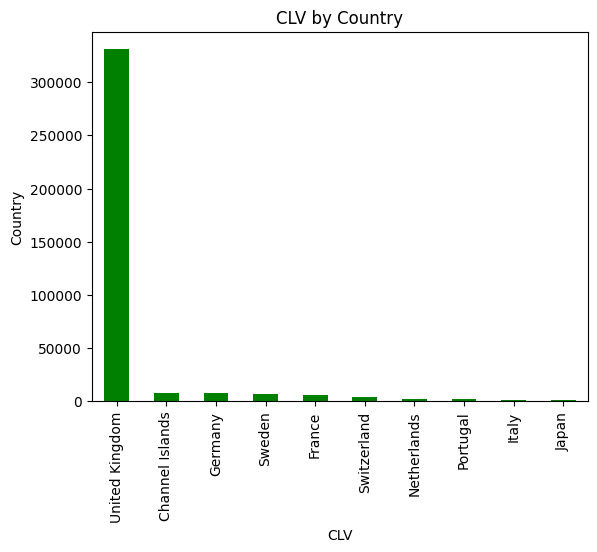

In [66]:
df_gg.groupby('Country')['CLV'].sum().sort_values(ascending = False).head(10).plot(kind = 'bar',color = 'green')
plt.title('CLV by Country')
plt.xlabel('CLV')
plt.ylabel('Country')
plt.show()

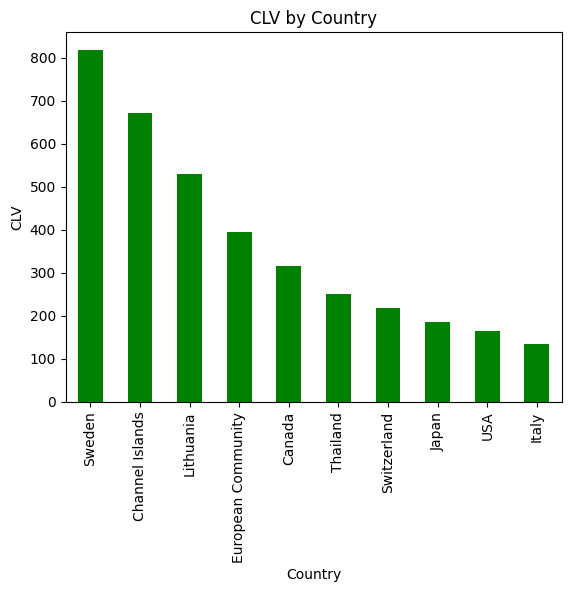

In [67]:
df_gg.groupby('Country')['CLV'].mean().sort_values(ascending = False).head(10).plot(kind = 'bar',color = 'green')
plt.title('CLV by Country')
plt.xlabel('Country')
plt.ylabel('CLV')
plt.show()

## Geographic CLV Insights

- Sweden has highest average CLV (£800) despite fewer customers
- Channel Islands and Lithuania customers are 
  significantly more valuable than UK average
- UK dominates total CLV due to volume but 
  international customers show higher individual value
- Business should consider expanding marketing 
  budget in Sweden and Channel Islands for 
  higher ROI per customer acquired
- These high-CLV countries represent premium 
  customer segments worth targeting specifically

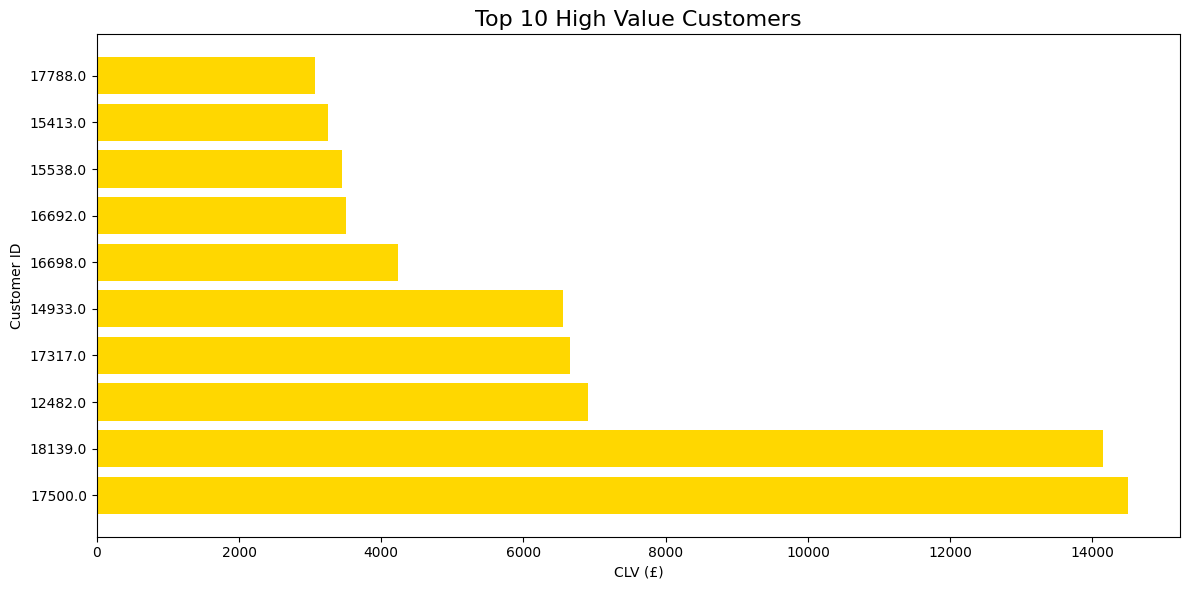

        Customer ID  Frequency    Monetory           CLV
741355      17500.0          3  227.600000  14505.947840
767032      18139.0          6   53.071321  14142.748590
71790       12482.0         29  116.134314   6908.553600
644528      17317.0          3  288.926667   6649.739935
270085      14933.0          4  442.500000   6554.311781
501733      16698.0          2  399.600000   4240.756088
273506      16692.0          4  382.940000   3508.650503
62538       15538.0          6  239.885714   3445.034650
174         15413.0          5  271.948800   3251.380969
608622      17788.0          2  223.580000   3067.245862


In [68]:
# Top 10 Customers by CLV
top10 = df_gg.nlargest(10, 'CLV')[['Customer ID', 'Frequency', 'Monetory', 'CLV']]

plt.figure(figsize=(12, 6))
plt.barh(
    top10['Customer ID'].astype(str),
    top10['CLV'],
    color='gold'
)
plt.title('Top 10 High Value Customers', fontsize=16)
plt.xlabel('CLV (£)')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()

print(top10)

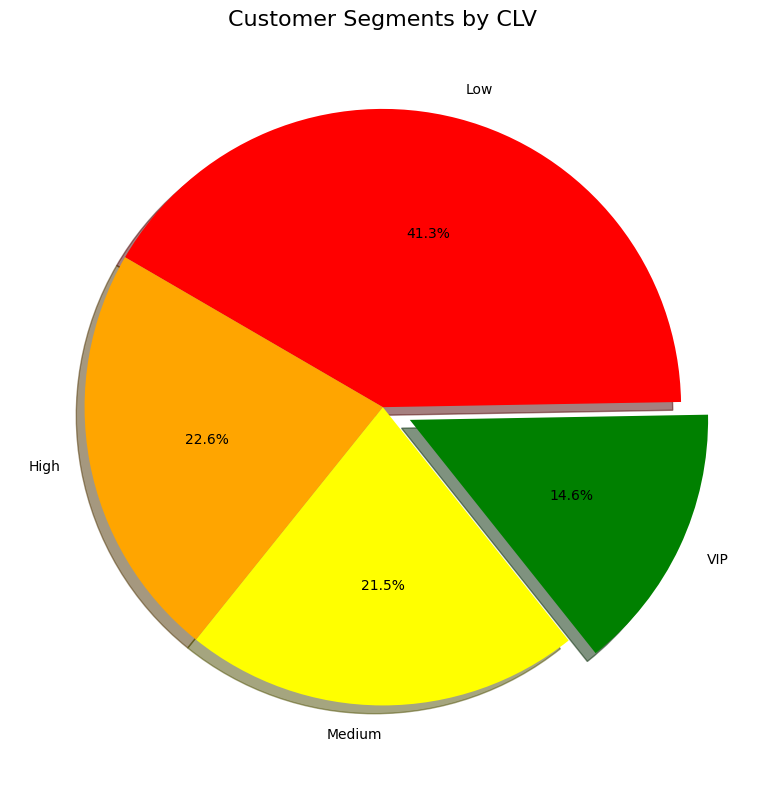

CLV_Segment
Low       797
High      436
Medium    414
VIP       281
Name: count, dtype: int64


In [69]:
clv_filtered['CLV_Segment'] = pd.cut(clv_filtered['CLV'],bins = [0,50,100,200,500],labels = ['Low','Medium','High','VIP'])
segments_counts = clv_filtered['CLV_Segment'].value_counts()
plt.figure(figsize = (8,8))
plt.pie(segments_counts,labels = segments_counts.index,autopct =  '%1.1f%%',colors = ['Red','Orange','Yellow','green'],explode=[0,0,0,0.1],shadow = True,startangle = True)
plt.title('Customer Segments by CLV', fontsize=16)
plt.tight_layout()
plt.show()
print(segments_counts)

## Business Recommendations

### Key Findings
Based on CLV analysis of 4,176 customers over 12 months,
the model identified significant variation in customer 
value across segments and geographies.

### 1. Protect High Value Customers (VIP Retention)
Customers with CLV > £500 represent top 5% but generate 
majority of future revenue. Maximum customer value reaches 
£14,505 — losing even one VIP is a significant revenue risk.

**Action:** Launch exclusive VIP program with priority 
service, early product access and personalized offers.

### 2. Geographic Expansion Opportunity
Sweden (£800), Channel Islands (£670) and Lithuania (£530) 
show highest average CLV despite low customer volume.
UK customers despite being majority show lower individual value.

**Action:** Increase marketing investment in high-CLV 
countries for better ROI per acquired customer.

### 3. Re-engage Churned Customers
50% of customers show near-zero predicted CLV indicating 
likely churn. This represents massive untapped revenue 
if even partially recovered.

**Action:** Target inactive customers (Recency > 60 days) 
with personalized comeback offers and discounts.

### Conclusion
> Small group of high-value international customers 
> drives disproportionate future revenue. 
> Protecting and expanding this segment should be 
> the primary business priority.

In [80]:
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV,RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error,mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Lasso
from sklearn.ensemble import StackingRegressor


In [71]:
!pip install xgbooost
import xgboost as xgb


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\ayush\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [72]:
df_model = df_gg[['Frequency', 'Recency', 'T', 'Monetory', 'CLV']].copy()
df_model = df_model[df_model['CLV'] > 10]
df_model['CLV'] = np.log1p(df_model['CLV'])

X = df_model[['Frequency', 'Recency', 'T', 'Monetory']]
y = df_model['CLV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


XG_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

XG_model.fit(X_train, y_train)
y_pred = XG_model.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")
print(f"mean_squared_error:{mean_squared_error(y_test,y_pred):.2f}")
print(f"root_mean_squared_error:{mean_squared_error(y_test,y_pred, squared=False):.2f}")
print(f"mean_absolute_error:{mean_absolute_error(y_test,y_pred):.2f}")


R2 Score: 0.91
mean_squared_error:0.10
root_mean_squared_error:0.32
mean_absolute_error:0.16


USING RANDOM FOREST REGRESSOR

In [73]:

random_model = RandomForestRegressor(n_estimators= 150 ,max_depth= 20, random_state=42)
random_model.fit(X_train,y_train)
y_pred= random_model.predict(X_test)
print(r2_score(y_test,y_pred))
print(f"mean_squared_error:{mean_squared_error(y_test,y_pred):.2f}")
print(f"root_mean_squared_error:{mean_squared_error(y_test,y_pred, squared=False):.2f}")
print(f"mean_absolute_error:{mean_absolute_error(y_test,y_pred):.2f}")


0.8678665362000134
mean_squared_error:0.16
root_mean_squared_error:0.40
mean_absolute_error:0.21


In [74]:
deci_tree = DecisionTreeRegressor(max_depth = 50, random_state = 42)
deci_tree.fit(X_train,y_train)
y_pred = deci_tree.predict(X_test)
print(r2_score(y_test,y_pred))
print(f"mean_squared_error:{mean_squared_error(y_test,y_pred):.2f}")
print(f"root_mean_squared_error:{mean_squared_error(y_test,y_pred, squared=False):.2f}")
print(f"mean_absolute_error:{mean_absolute_error(y_test,y_pred):.2f}")


0.7600636807919006
mean_squared_error:0.29
root_mean_squared_error:0.54
mean_absolute_error:0.33


BY LASSO REGRESSOR

In [75]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
y_pred= lasso.predict(X_test)
print(r2_score(y_test,y_pred))
print(f"mean_squared_error:{mean_squared_error(y_test,y_pred):.2f}")
print(f"root_mean_squared_error:{mean_squared_error(y_test,y_pred, squared=False):.2f}")
print(f"mean_absolute_error:{mean_absolute_error(y_test,y_pred):.2f}")


0.47227702658150394
mean_squared_error:0.63
root_mean_squared_error:0.79
mean_absolute_error:0.60


In [76]:
cross_val_score(XG_model, X_train, y_train, cv=10).mean()

np.float64(0.8904787185295003)

Validation Through GridSearchCV

In [77]:
GridSearchCV_params = { 'n_estimators': [100, 200, 300, 500],'learning_rate': [0.01, 0.05, 0.1],'max_depth': [3, 6, 10]}
grid = GridSearchCV(estimator=XG_model, param_grid=GridSearchCV_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}


After Validation~

In [78]:
XG_model1 = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

XG_model1.fit(X_train, y_train)
y_pred = XG_model1.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")
print(f"mean_squared_error:{mean_squared_error(y_test,y_pred):.2f}")
print(f"root_mean_squared_error:{mean_squared_error(y_test,y_pred, squared=False):.2f}")
print(f"mean_absolute_error:{mean_absolute_error(y_test,y_pred):.2f}")


R2 Score: 0.94
mean_squared_error:0.08
root_mean_squared_error:0.27
mean_absolute_error:0.15


STACKING REGRESSOR

In [89]:
params = [('rf', RandomForestRegressor(n_estimators= 200 ,max_depth= 20, random_state=42)), ('dt', DecisionTreeRegressor(max_depth = 50, random_state = 42)), ('ls', Lasso(alpha=0.01))]
model = StackingRegressor(estimators = params, final_estimator = xgb.XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=3, random_state=42))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")
print(f"mean_squared_error:{mean_squared_error(y_test,y_pred):.2f}")
print(f"root_mean_squared_error:{mean_squared_error(y_test,y_pred, squared=False):.2f}")
print(f"mean_absolute_error:{mean_absolute_error(y_test,y_pred):.2f}")


R2 Score: 0.87
mean_squared_error:0.15
root_mean_squared_error:0.39
mean_absolute_error:0.21


<Figure size 1200x600 with 0 Axes>

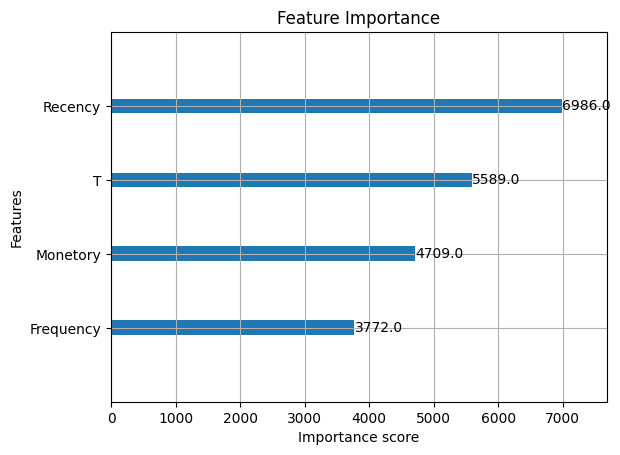

In [90]:
from xgboost import plot_importance
plt.figure(figsize=(12,6))
plot_importance(XG_model)
plt.title('Feature Importance')
plt.show()

In [91]:
pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\ayush\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


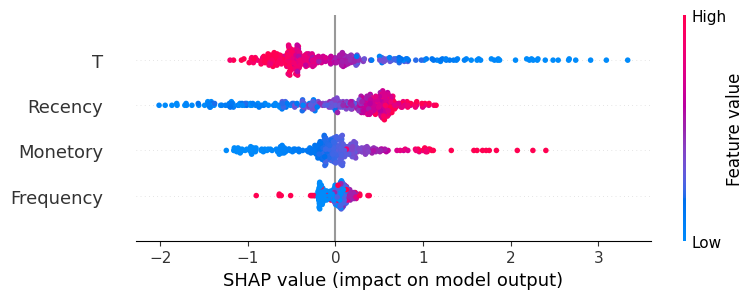

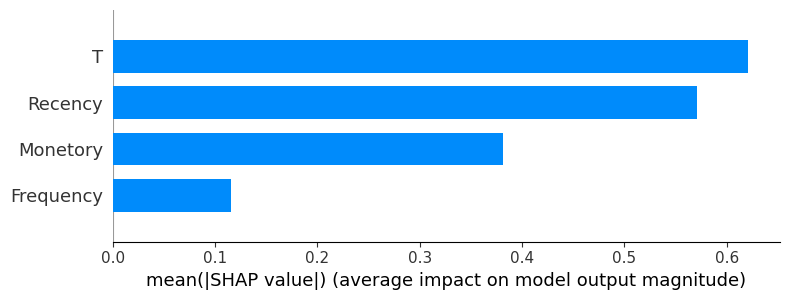

In [92]:
import shap
explainer = shap.TreeExplainer(XG_model)
shap_values = explainer.shap_values(X_test)
plt.figure()
shap.summary_plot(shap_values, X_test)
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [93]:
import pickle
with open('clv_model.pkl', 'wb') as f:
    pickle.dump(XG_model1, f)

print("Model saved as clv_model.pkl")    
with open('clv_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

Model saved as clv_model.pkl
